BORDES

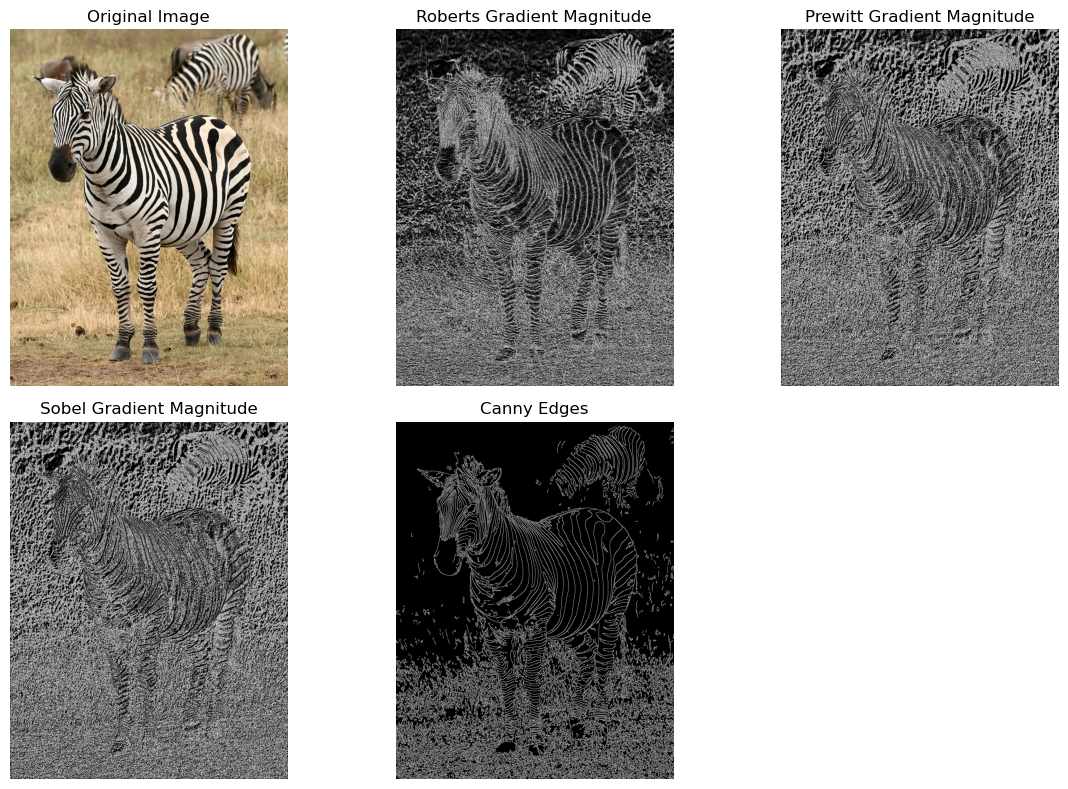

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('zebra.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
robertx = np.array([[-1, 0,], [0, 1]])
roberty = np.array([[0, -1], [1, 0]])
robx_img = cv2.filter2D(gray, -1, robertx)
roby_img = cv2.filter2D(gray, -1, roberty)
rob_grad= np.sqrt(robx_img**2 + roby_img**2)
rob_grad_dir = np.arctan2(roby_img, robx_img)

#prewit

prewit_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewit_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
prex_img = cv2.filter2D(gray, -1, prewit_x)
prey_img = cv2.filter2D(gray, -1, prewit_y)
prewit_mag = np.sqrt(prex_img**2 + prey_img**2)
prewit_dir = np.arctan2(prey_img, prex_img)

#sobel

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])    
sobelx_img = cv2.filter2D(gray, -1, sobel_x)
sobely_img = cv2.filter2D(gray, -1, sobel_y)
sobel_mag = np.sqrt(sobelx_img**2 + sobely_img**2)
sobel_dir = np.arctan2(sobely_img, sobelx_img)

#cany

canny_img = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(15, 20))

# Roberts
plt.subplot(4, 3, 1)
plt.title('Roberts X')
plt.imshow(robx_img, cmap='gray')
plt.axis('off')
plt.subplot(4, 3, 2)
plt.title('Roberts Y')
plt.imshow(roby_img, cmap='gray')
plt.axis('off')
plt.subplot(4, 3, 3)
plt.title('Roberts Gradient Magnitude')
plt.imshow(rob_grad, cmap='gray')
plt.axis('off')

# Prewitt
plt.subplot(4, 3, 4)
plt.title('Prewitt X')
plt.imshow(prex_img, cmap='gray')
plt.axis('off')
plt.subplot(4, 3, 5)
plt.title('Prewitt Y')
plt.imshow(prey_img, cmap='gray')
plt.axis('off')
plt.subplot(4, 3, 6)
plt.title('Prewitt Gradient Magnitude')
plt.imshow(prewit_mag, cmap='gray')
plt.axis('off')

# Sobel
plt.subplot(4, 3, 7)
plt.title('Sobel X')
plt.imshow(sobelx_img, cmap='gray')
plt.axis('off')
plt.subplot(4, 3, 8)
plt.title('Sobel Y')
plt.imshow(sobely_img, cmap='gray')
plt.axis('off')
plt.subplot(4, 3, 9)
plt.title('Sobel Gradient Magnitude')
plt.imshow(sobel_mag, cmap='gray')
plt.axis('off')

# Original & Canny
plt.subplot(4, 3, 10)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(4, 3, 11)
plt.title('Canny Edges')
plt.imshow(canny_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

SOBEL

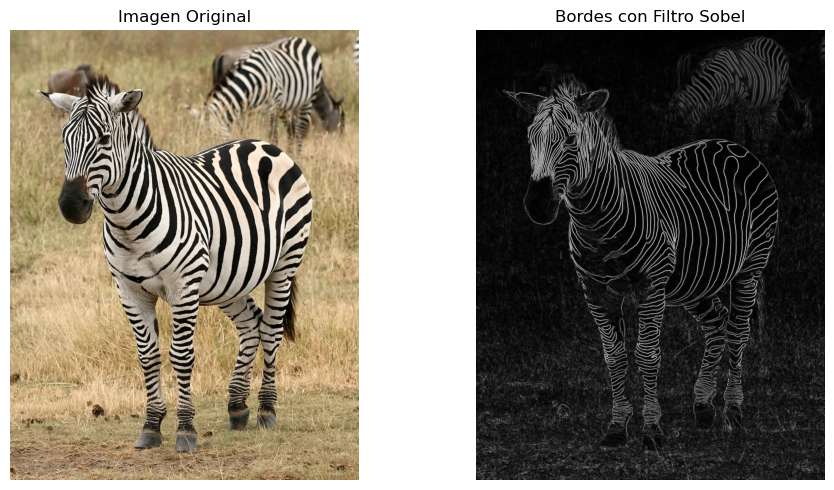

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)

    mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    return mag

img = cv2.imread('zebra.jpg')
sobel_result = filtro_sobel(img)    
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Bordes con Filtro Sobel')
plt.imshow(sobel_result, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

SOBEL MEJORADO

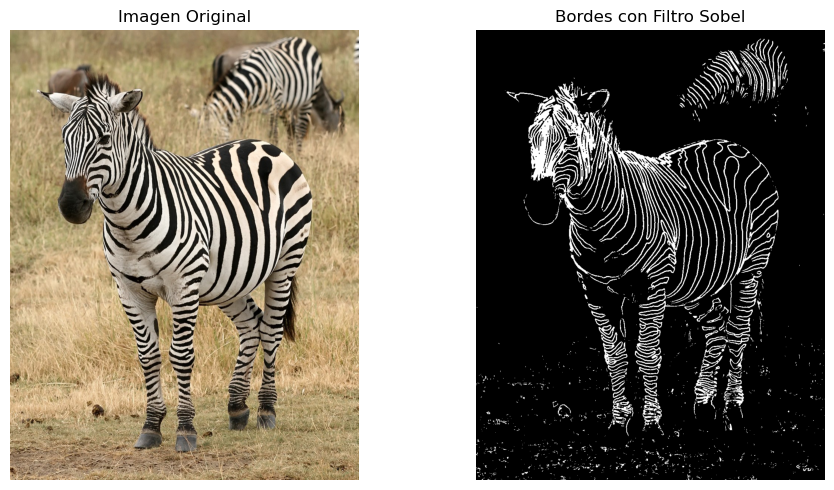

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img, kernel_size=3, umbral= 30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gris = cv2.GaussianBlur(img_gris, (3, 3), 0)
    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=kernel_size)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=kernel_size)

    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _, bordes = cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel_m = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_m)
    return bordes

img = cv2.imread('zebra.jpg')
sobel_result = filtro_sobel(img)    
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Bordes con Filtro Sobel')
plt.imshow(sobel_result, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

ROBERT FILTER

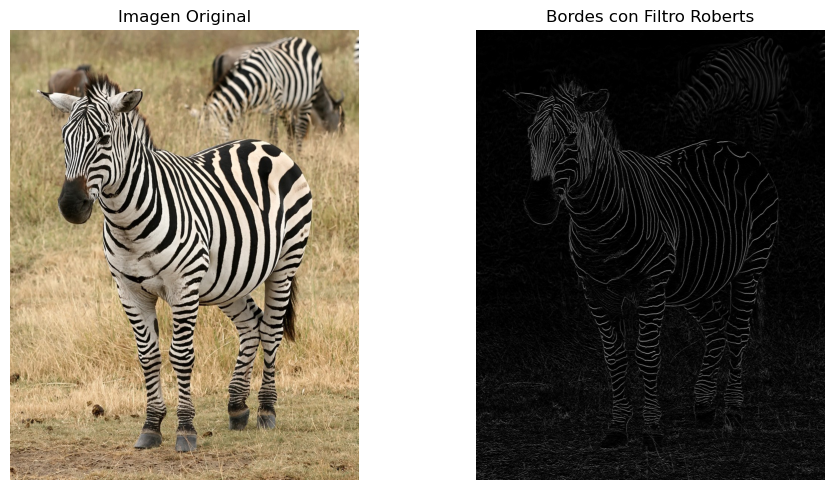

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    robertx = np.array([[-1, 0], [0, 1]], dtype=np.float32)
    roberty = np.array([[0, -1], [1, 0]], dtype=np.float32)
    r_x = cv2.filter2D(img_gris, -1, robertx)
    r_y = cv2.filter2D(img_gris, -1, roberty)
    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    return roberts

img = cv2.imread('zebra.jpg')
roberts_result = filtro_roberts(img)    
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Bordes con Filtro Roberts')
plt.imshow(roberts_result, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()